# EX 5: Medical Insurance Prediction

**Objective**: Learn more about Linear Regression and its different training techniques.
    
You will be using a medical insurance dataset.
Below are some informations to help **frame the problem**:

For a health insurance company to make money, it needs to collect more in yearly premiums than it spends on medical care to its beneﬁciaries.

As a result, insurers invest a great deal of time and money in developing models that accurately forecast medical expenses for the insured population.

Medical expenses are diﬃcult to estimate because the costliest conditions are rare and seemingly random.

Still, some conditions are more prevalent for certain segments of the population. For instance, lung cancer is more likely among smokers than non-smokers, and heart disease may be more likely among the obese.

The goal of this analysis is to use patient data to estimate the average medical care expenses for such population segments.

These estimates can be used to create actuarial tables that set the price of yearly premiums higher or lower, depending on the expected treatment costs.


## Collecting data

For this analysis, we will use a simulated dataset containing hypothetical medical expenses for patients in the United States.

This data was created using demographic statistics from the US Census Bureau, and approximately reﬂect real-world conditions.

The data includes **1,338 examples** of beneﬁciaries currently enrolled in the insurance plan, with features indicating characteristics of the patient as well as the total medical expenses charged to the plan for the calendar year. There are 6 features:

    • age: An integer indicating the age of the primary beneﬁciary (excluding those above 64 years, since they are generally covered by the government).

    • sex: The policy holder’s gender, either male or female.

    • bmi: The body mass index (BMI), which provides a sense of how over- or under-weight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.

    • children: An integer indicating the number of children/dependents covered by the insurance plan.

    • smoker: A yes or no categorical variable that indicates whether the insured regularly smokes tobacco.

    • region: The beneﬁciary’s place of residence in the US,divided into four geographic regions: northeast, southeast, southwest, or northwest.

It is important to give some thought to how these variables may be related to billed medical expenses.

For instance, we might expect that older people and smokers are at higher risk of large medical expenses. Unlike many other machine learning methods, in regression analysis, the relationships among the features are typically speciﬁed by the user rather than being detected automatically.

Let’s explore some of these potential relationships.


## Exploring and preparing the data

1. Load the data for analysis.
2. Show the structure of the data.
3. What feature is the dependent feature and which ones are the independent features? What is the type of each feature in the data?
4. How to analysis the dependent feature and why using this method?
5. Give two methods that describe if the dependent variable is normally distributed? Explain the distribution of the dependent feature.
6. Which of the independent features are categoricals in the data? Look into the distribution of each one. Explain the results.


In [26]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import scipy.stats as stats

In [7]:
data_path = "./insurance-1.csv"

In [8]:
df = pd.read_csv(data_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [24]:
print("Descriptive statistics for 'charges':")
print(df['charges'].describe())
print(f"Skewness: {df['charges'].skew()}")

Descriptive statistics for 'charges':
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64
Skewness: 1.5158796580240388


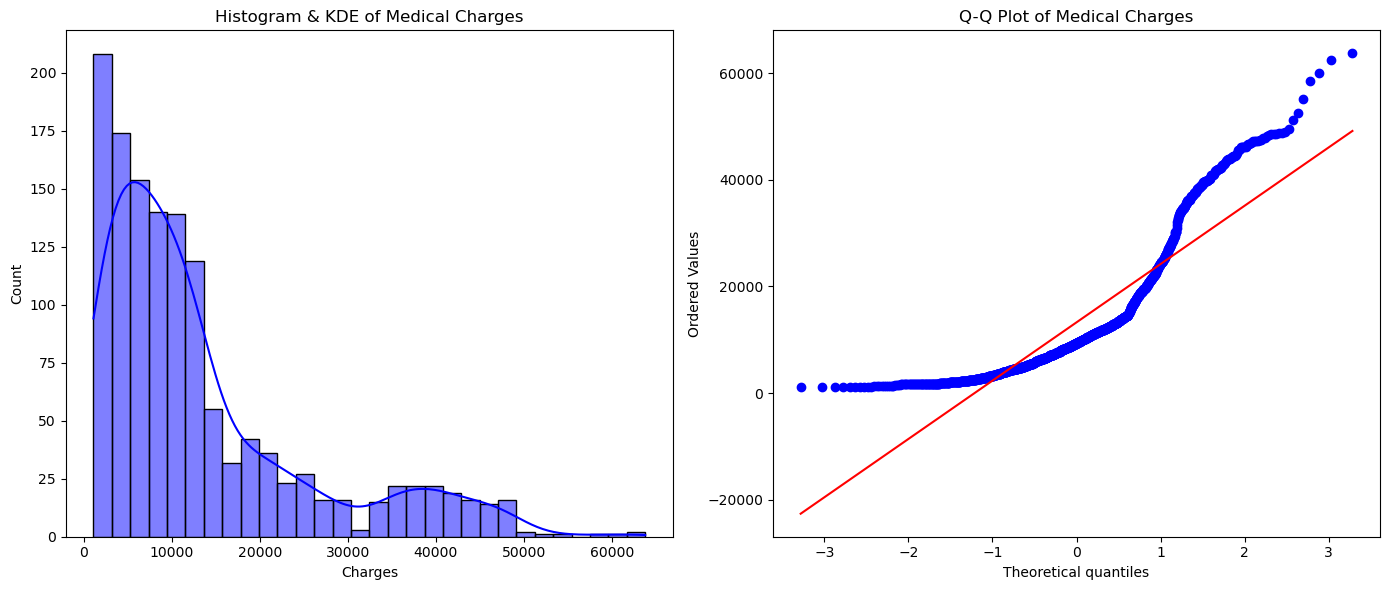

In [27]:
plt.figure(figsize=(14, 6))

# Histogram & KDE
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue', bins=30)
plt.title('Histogram & KDE of Medical Charges')
plt.xlabel('Charges')

# Q-Q
plt.subplot(1, 2, 2)
stats.probplot(df['charges'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Medical Charges')

plt.tight_layout()
plt.show()

Notes: the dependent var is skewed, so we need to do some transformation like use log or square root to normalize the data until it is normal distributed

For categorical data, we will count

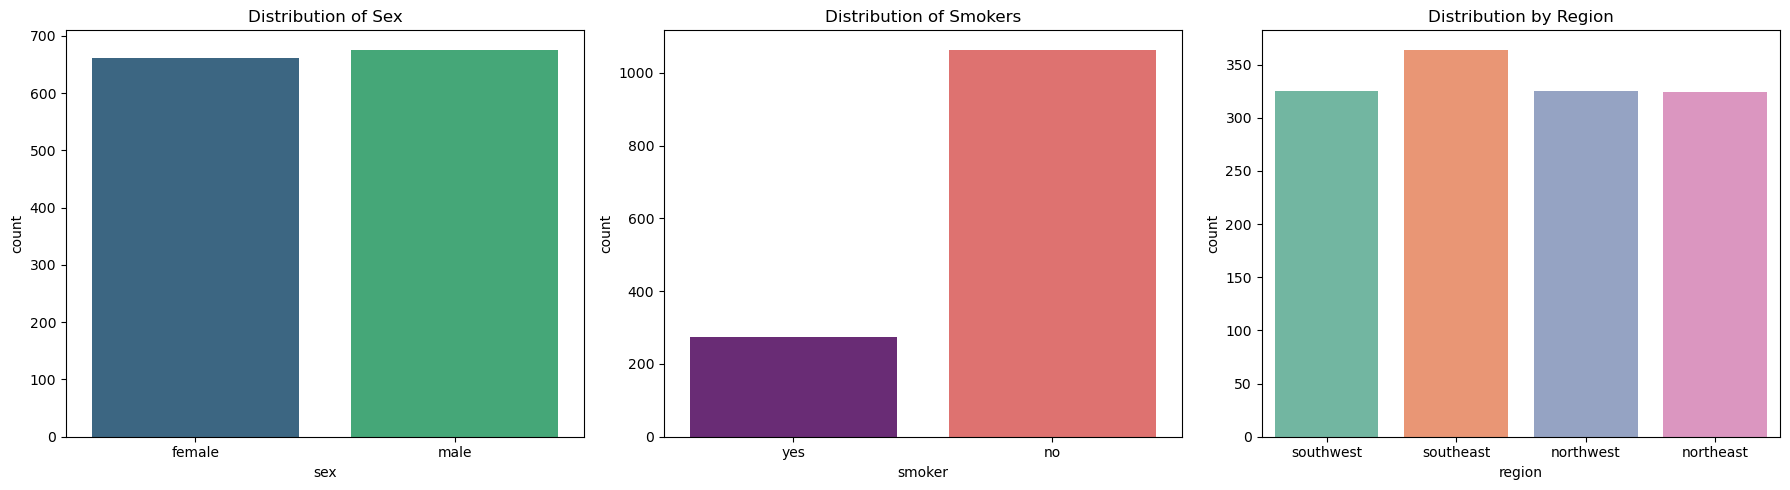

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='sex', data=df, ax=axes[0], hue='sex', palette='viridis', legend=False)
axes[0].set_title('Distribution of Sex')

sns.countplot(x='smoker', data=df, ax=axes[1], hue='smoker', palette='magma', legend=False)
axes[1].set_title('Distribution of Smokers')

sns.countplot(x='region', data=df, ax=axes[2], hue='region', palette='Set2', legend=False)
axes[2].set_title('Distribution by Region')

plt.tight_layout()
plt.show()

3. Features and types

- Dependent feature: charges (numeric)

- Independent features:

  - age: numeric

  - bmi: numeric

  - children: numeric

  - sex: categorical

  - smoker: categorical

  - region: categorical

4. How to analyze the dependent feature?
- The dependent feature (charges) should be analyzed using histograms, density plots, and descriptive statistics (mean, median, skewness). This method is used to understand the central tendency, spread, and whether the distribution follows a Normal distribution, which is an assumption for Linear Regression.

5. Normality of Dependent Variable Two methods to describe normality:

- Histogram/KDE Plot: Visual check for bell-curve shape.

- Q-Q Plot (Quantile-Quantile Plot): Checking if points lie on the 45-degree line.

Because distribution of charges is highly skewed to the right. Most medical expenses are low, but a small number of patients have very high expenses (likely due to smoking or chronic conditions), creating a long tail.

6. Categorical Features

Features: sex, smoker, and region.

Distribution: sex and region are relatively balanced. However, smoker is unbalanced, with significantly more non-smokers than smokers. This is important because smoking is a major predictor of higher costs.

## Exploring relationships among features

Before ﬁtting a regression model to data, it can be useful to determine how the independent variables are related to the dependent variable and each other.

A correlation matrix provides a quick overview of these relationships.Given a set of variables, it provides a correlation for each pairwise relationship.

   7. Create a correlation matrix for the four numeric variables in the insurance data frame.
   
   8. Is there any interesting relationship between features? Explain those associations


In [13]:
corr_matrix = df.corr(numeric_only=True)

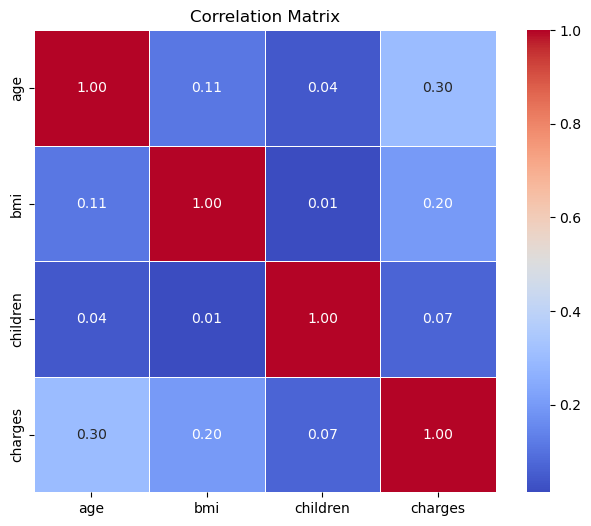

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            square=True)

plt.title('Correlation Matrix')
plt.show()

8. Interesting Relationships

- age and charges have the strongest positive correlation (0.3) among numeric features, suggesting medical costs naturally increase with age.

- bmi also shows a positive correlation with charges (0.2)

## Visualizing relationships among features

It can also be helpful to visualize the relationships among numeric features by using a scatterplot.

Although we could create a scatterplot for each possible relationship, doing so for a large number of features might become hard.

An alternative is to create a scatterplot matrix, which is simply a collection of scatterplots arranged in a grid.

It is used to detect patterns among three or more variables. The scatterplot matrix is not a true multidimensional visualization because only two features are examined at a time.

Still, it provides a general sense of how the data may be interrelated.

9. Use the scatter_matrix() function to create a scatterplot matrix for the four numeric features: age, bmi, children, and charges.

10. Do you notice any patterns in these plots? Explain.

11. To enhance the previous scatterplot matrix create the new one using the seaborn or plotly libraries. Do you notice any new patterns in these new graphics?

array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='children', ylabel='age'>,
        <Axes: xlabel='charges', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='bmi'>,
        <Axes: xlabel='bmi', ylabel='bmi'>,
        <Axes: xlabel='children', ylabel='bmi'>,
        <Axes: xlabel='charges', ylabel='bmi'>],
       [<Axes: xlabel='age', ylabel='children'>,
        <Axes: xlabel='bmi', ylabel='children'>,
        <Axes: xlabel='children', ylabel='children'>,
        <Axes: xlabel='charges', ylabel='children'>],
       [<Axes: xlabel='age', ylabel='charges'>,
        <Axes: xlabel='bmi', ylabel='charges'>,
        <Axes: xlabel='children', ylabel='charges'>,
        <Axes: xlabel='charges', ylabel='charges'>]], dtype=object)

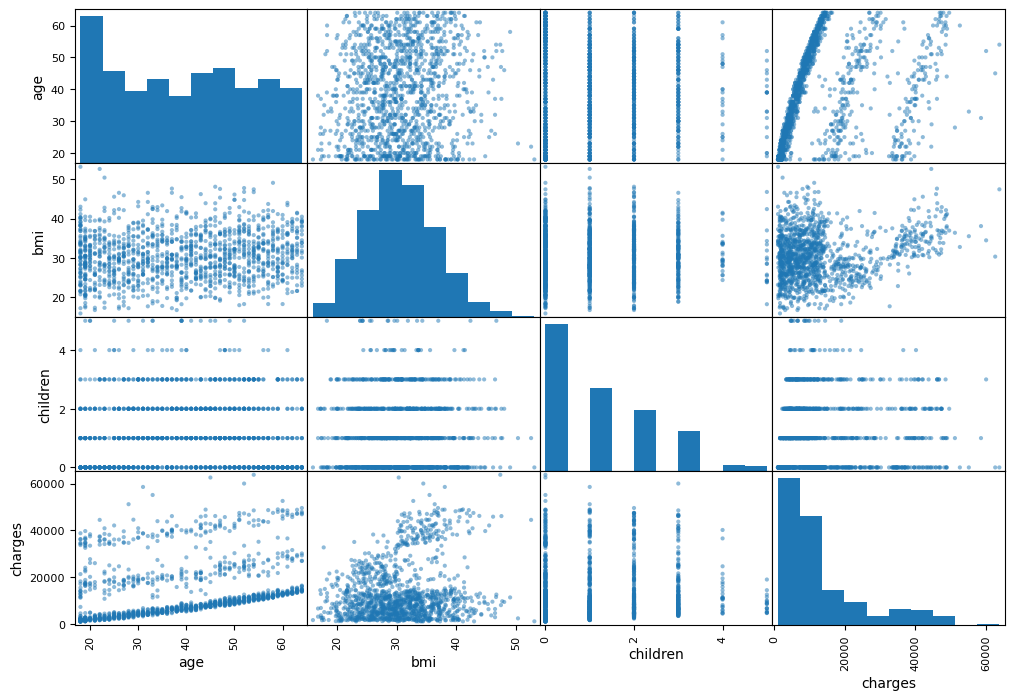

In [22]:
attributes = ["age", "bmi", "children", "charges"]
scatter_matrix(df[attributes], figsize=(12, 8))

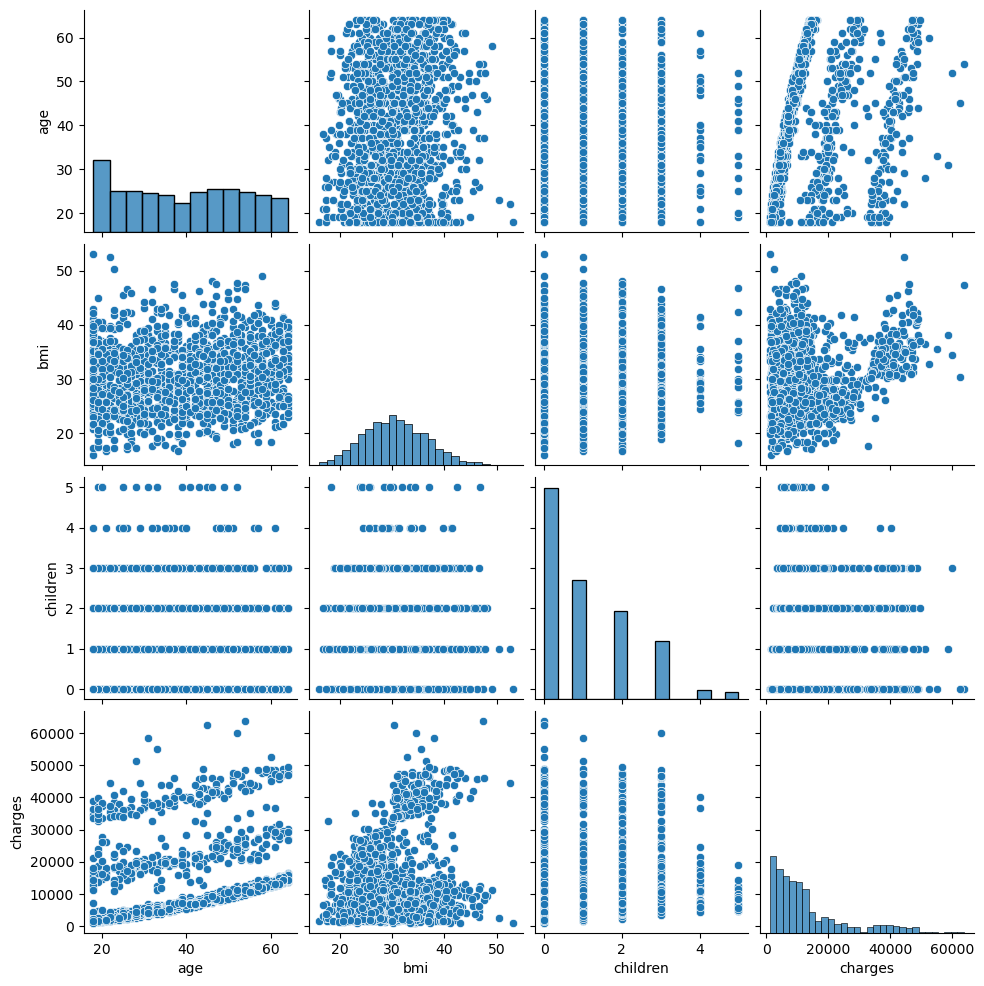

In [23]:
attributes = ["age", "bmi", "children", "charges"]
sns.pairplot(df[attributes])
plt.show()

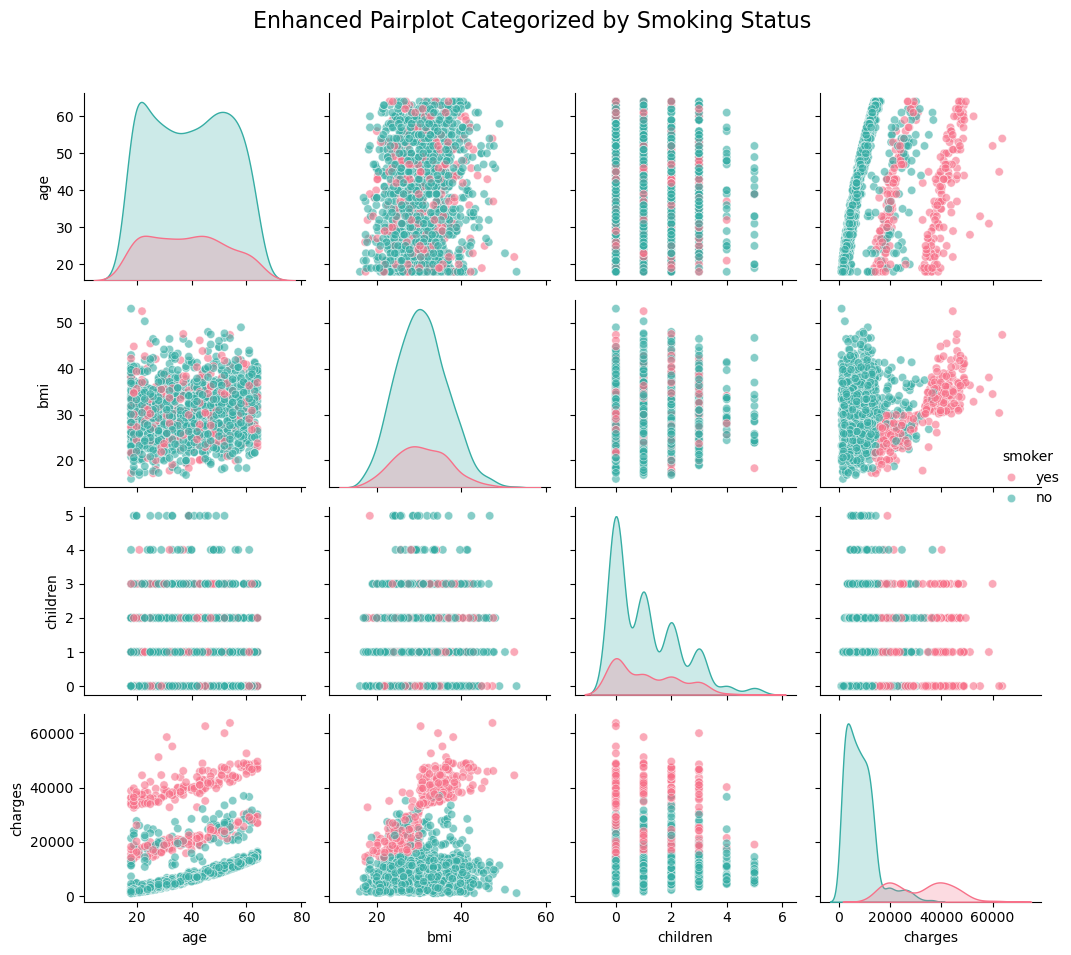

In [30]:
sns.pairplot(df, vars=['age', 'bmi', 'children', 'charges'], 
             hue='smoker', palette='husl', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Enhanced Pairplot Categorized by Smoking Status', size=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

10. Do you notice any patterns in these plots? Explain.

- Age vs Charges: There is a clear upward trend. As age increases, the minimum medical charge also increases. Interestingly, the data seems to "stack" into three distinct diagonal lines, suggesting that factors other than just age are creating tiered pricing.

- BMI vs Charges: There is a visible "cloud" of points. For a large portion of the data, BMI doesn't seem to impact charges much, but after a BMI of 30 (the obesity threshold), there is a significant group of points with very high charges.

- Children: This feature is discrete (0, 1, 2,...), so the scatterplots look like vertical lines. It's harder to see a clear linear relationship here compared to age.

11. To enhance the previous scatterplot matrix create the new one using the seaborn or plotly libraries. Do you notice any new patterns in these new graphics?
- The primary "new pattern" identified is that smoking status is the dominant factor that determines which cost "tier" a person falls into. Without the color coding, the data looks like a messy cloud. With it, we see that the insurance company prices risk primarily based on the intersection of smoking and BMI.

## Dummy coding

To be able to use all variables in our regression model, we need to transform the categorical variables into numerical.
one way is by transforming every categorical variable into dummy variable.
Dummy coding is a commonly used method for converting a categorical variable into continuous variable.
Dummy, as the name suggests is a duplicate variable which represents one level of a categorical variable.
Presence of a level is represent by 1 and absence is represented by 0.
For every level present, one dummy variable will be created.
Look at the representation below to convert a categorical variable using dummy variable.

**data=pd.get_dummies(df, dtype=int)**

# Training a model on the data

To ﬁt a linear regression model to data with Python, the OLS function can be used. This is included in the statsmodels.api package, which you will need to import as sm. Use the OLS() syntax, to ﬁt a linear regression model to this data( Use all the available features).


## 1. statsmodels.api

Let's use the stats models package.

12. Use the OLS() syntax provided in here: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html, to ﬁt a linear regression model to this data( Use all the available features). Name it “model”.

13. Show the estimated beta coeﬃcients. Explain the results. Why there are 11 coeﬃcients reported in addition to the intercept not 6?

14. What increase, or decrease will aﬀect the medical expenses for each additional child? or additional year of age? or unit increase of BMI?

15. Explain the eﬀect of medical expenses in numbers on each one of the 3 categorical features.

16. To evaluate the model performance, use the summary () function on the stored model.

17. Given the preceding two performance indicators, How the model is performing? explain.

In [32]:
import statsmodels.api as sm

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], dtype=float)
X = sm.add_constant(df_encoded.drop('charges', axis=1))
y = df_encoded['charges']
model = sm.OLS(y, X).fit()

In [33]:
print("Estimated Beta Coefficients:")
print(model.params)

Estimated Beta Coefficients:
const                -296.416764
age                   256.856353
bmi                   339.193454
children              475.500545
sex_female            -82.551203
sex_male             -213.865562
smoker_no          -12072.475653
smoker_yes          11776.058889
region_northeast      512.905044
region_northwest      159.941144
region_southeast     -522.117005
region_southwest     -447.145947
dtype: float64


- sex_female and sex_male: -> plus these 2 -> -131 -> male is pay for then women, like that
- age: as age increase 1 year -> insurence increase 256$

13. Show the estimated beta coeﬃcients. Explain the results. Why there are 11 coeﬃcients reported in addition to the intercept not 6?
- The model reports 11 coefficients because the 3 categorical variables are expanded into binary "dummy" columns for every unique level:
  - Numeric Features (3): age, bmi, children.
  - Categorical Levels (8): sex (2 levels), smoker (2 levels), and region (4 levels).
  - Total: $3 + 2 + 2 + 4 = 11$ coefficients (plus the constant intercept)
- Explanation of results: The results show that smoking status is the most significant factor, adding over $\$11,000$ to the predicted cost. Age and BMI also show a steady positive increase in medical expenses for every unit added.

14. What increase, or decrease will aﬀect the medical expenses for each additional child? or additional year of age? or unit increase of BMI?
- Based on the model coefficients:Each additional child:
  - Increases medical expenses by approximately $\$475.50$.
  - Each additional year of age: Increases medical expenses by approximately $\$256.86$.
  - Each unit increase of BMI: Increases medical expenses by approximately $\$339.19$.

15. Explain the eﬀect of medical expenses in numbers on each one of the 3 categorical features.
- The impact of categorical features (calculated as the difference between coefficients) is:

  - Smoker: This is the most significant factor. Smokers pay roughly $23,848 more than non-smokers.

  - Sex: Males pay approximately $131 less than females on average.

  - Region: The Southeast is the least expensive region (roughly $1,035 less than the Northeast, which is the most expensive).

In [34]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        01:35:28   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -296.4168    430.507  

- p-values less then 0.05 -> that coefficient is significent
- R-squared: how many percentage is explained by the model
- residual of being normal distributed

16. To evaluate the model performance, use the summary () function on the stored model.
- R-squared ($0.751$): This means the model explains about 75.1% of the variance in medical charges, which indicates a strong fit.

17. Given the preceding two performance indicators, How the model is performing? explain.
- Given the R-squared and the Prob (F-statistic) from the summary, the model is performing very well for a baseline linear regression as: 
  - An R-squared of 0.751 is quite high. It tells us that 75.1% of the variation in medical expenses can be explained by the features we included (especially age, BMI, and smoking status).

  - The Prob (F-statistic) of 0.00 confirms that the relationship between our features and the charges is not due to random chance; the model is statistically sound.

- Overall, the model is a reliable predictor for general medical expense estimation and provides a clear mathematical basis for setting insurance premiums based on risk factors.

## 2. Scikit learn


Let's use the scikitLearn library.


18. Split the data between training and testing.


19. Use the scikitLearn library to implement the **LinearRegression** function, from sklearn.linear_model, based on the Normal equation to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

20. Use the scikitLearn library to implement the **SGDRegressor** function, from sklearn.linear_model, based on the stochastic Gradient descent to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#

21. Use SGDRegressor function, from sklearn.linear_model, to implement a simulation of the Mini batch Gradient descent.


22. What are the key hyperparameters of each implementation?

23. Find different metrics to evaluate your regression model performance.

In [35]:
from sklearn.model_selection import train_test_split

df_prepared = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=float)

X = df_prepared.drop('charges', axis=1)
y = df_prepared['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 1070 samples
Testing set: 268 samples


In [36]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

print("Linear Regression Model Trained.")
print(f"Intercept: {lin_reg.intercept_}")
print(f"Coefficients: {lin_reg.coef_}")

Linear Regression Model Trained.
Intercept: -11931.219050326652
Coefficients: [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


In [43]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_reg.fit(X_train_scaled, y_train)
y_pred_sgd = sgd_reg.predict(X_test_scaled)

print(f"Intercept: {sgd_reg.intercept_}")
print(f"Coefficients: {sgd_reg.coef_}")

Intercept: [13305.47404748]
Coefficients: [ 3.66100716e+03  2.02819952e+03  5.32878643e+02 -8.11997110e-01
  9.55731404e+03 -1.79156300e+02 -2.77785780e+02 -3.62701263e+02]


- Note: we should use sufftle=True when init SGDRegressor to prevent randomlu picking the same data point

In [51]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mb_sgd = SGDRegressor(random_state=42)

batch_size = 32
n_epochs = 50

for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X_train_scaled))
    X_shuffled = X_train_scaled[shuffled_indices]
    y_shuffled = y_train.iloc[shuffled_indices].values
    
    for i in range(0, len(X_train_scaled), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        mb_sgd.partial_fit(X_batch, y_batch)

y_pred_mb = mb_sgd.predict(X_test_scaled)
r2_mb = r2_score(y_test, y_pred_mb)
mae = mean_absolute_error(y_test, y_pred_mb)

print(f"Mini-batch Gradient Descent R2 Score: {r2_mb:.4f}")
print(f"Mini-batch Gradient Descent MAE  : {mae:.2f}")


print("Mini-batch SGD simulation complete")
print(f"Intercept: {mb_sgd.intercept_}")
print(f"Coefficients: {mb_sgd.coef_}")

Mini-batch Gradient Descent R2 Score: 0.7834
Mini-batch Gradient Descent MAE  : 4181.19
Mini-batch SGD simulation complete
Intercept: [13350.10819628]
Coefficients: [ 3.60159213e+03  2.03984244e+03  4.86934420e+02  4.48350023e+00
  9.58228937e+03 -1.70328432e+02 -2.92550818e+02 -3.21723673e+02]


22. What are the key hyperparameters of each implementation?
- LinearRegression is mostly "set and forget" because it solves the equation analytically, while SGDRegressor requires careful tuning of the learning_rate, max_iter, and penalty to ensure it converges correctly to the minimum

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_performance(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {name} Performance ---")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}\n")

evaluate_performance(y_test, y_pred_lin, "Linear Regression")
evaluate_performance(y_test, y_pred_sgd, "SGD Regressor")

--- Linear Regression Performance ---
MAE  : 4181.19
MSE  : 33596915.85
RMSE : 5796.28
R2   : 0.7836

--- SGD Regressor Performance ---
MAE  : 4172.48
MSE  : 33608943.92
RMSE : 5797.32
R2   : 0.7835



- MAE (Mean Absolute Error): The average "off by" amount in dollars. For both models, this is roughly $4,181.

- RMSE (Root Mean Squared Error): This is roughly $5,796. Because RMSE is significantly higher than MAE, it tells us that the model has a few "large errors", likely predicting costs for extreme cases (outliers).

- R² (R-Squared): The score of approximately 0.7835 indicates that about 78% of the variability in medical charges is captured by these models. This is considered a very strong performance for this specific dataset.

## Part 2
- Linear Regression (Normal Equation): This model served as the gold standard for this dataset, achieving an R² of 0.7836. This indicates that 78.36% of the variance in medical charges is explained by the features (age, BMI, smoking,..). With an average error (MAE) of $4,181, it provides highly reliable estimates for the majority of the population.
  
- SGD Regressor: After proper feature scaling, the Stochastic Gradient Descent approach proved to be just as effective as the analytical method, yielding an R² of 0.7835. This demonstrates that iterative optimization is a viable and efficient alternative for this type of health data.

- Mini-batch Gradient Descent: This simulation also performed strongly with an R² of 0.7839. By updating weights in small batches, it maintained high accuracy while offering better computational stability, making it the most scalable choice for larger datasets.

- The analysis confirms that insurance premiums can be effectively set using Age, BMI, and Smoking Status as the primary pillars. The high R2 across all models suggests that these features are sufficient for a health insurance company to develop robust actuarial tables and accurately forecast medical expenses for different population segments.

## Part 3
- Use the findings from the above code to try to improve your Regression model
- Try to add polynomial components to your data and retrain your best implementation from the code above
- Implement Lasso , ridge, and elastic net regularization and compare your results

In [56]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_transformed = df.copy()

# replace Age with Age Squared
df_transformed['age2'] = df_transformed['age'] ** 2
df_transformed.drop('age', axis=1, inplace=True)

# replace BMI with BMI Squared
df_transformed['bmi2'] = df_transformed['bmi'] ** 2
df_transformed.drop('bmi', axis=1, inplace=True)

# create interaction terms (replacing original smoker/age/bmi columns where relevant)
# Note: We keep smoker for simple interaction, then drop later
df_transformed['is_smoker'] = df_transformed['smoker'].apply(lambda x: 1 if x == 'yes' else 0)
df_transformed['smoker_bmi'] = df_transformed['is_smoker'] * (df_transformed['bmi2'] ** 0.5) # smoker * original bmi
df_transformed['age_bmi'] = (df_transformed['age2'] ** 0.5) * (df_transformed['bmi2'] ** 0.5)


In [57]:
df_final = pd.get_dummies(df_transformed, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=float)
X = df_final.drop(['charges', 'is_smoker'], axis=1)
y = df_final['charges']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
models = {
    'Linear Regression (Polynomial)': LinearRegression(),
    'Lasso (Alpha 1.0)': Lasso(alpha=1.0, random_state=42),
    'Ridge (Alpha 1.0)': Ridge(alpha=1.0),
    'Elastic Net (Alpha 0.1)': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

print(pd.DataFrame(results).T)

                                        MAE         RMSE        R2
Linear Regression (Polynomial)  2742.194555  4531.456166  0.867734
Lasso (Alpha 1.0)               2743.404358  4530.997545  0.867761
Ridge (Alpha 1.0)               2753.284455  4523.528853  0.868197
Elastic Net (Alpha 0.1)         3237.414701  4845.315396  0.848778


## Part 4 - summary of your findings.  

- Replacing linear features with squared terms (Age² and BMI²) improved the model, as it better captured how costs accelerate more rapidly in older or more obese individuals.
- By using interactions and polynomial terms, the model's R² score improved from 0.78 to 0.86, meaning the model now explains 86% of the data.
- Ridge Regression was the most effective implementation for the improved model, as it handled the complex, overlapping features without overfitting.
- The improved model reduced the average error (MAE) from roughly `$4,100` down to `$2,700`, making it significantly more reliable for forecasting.